# RSO-901 Glycol Set Points — Single Day

Look at the chiller glycol **set point** changes for a single `day_obs` using the
`lsst.sal.HVAC.logevent_chillerConfiguration` event. Each of the four HVAC chillers is shown in its
own panel (one column, shared time axis). A set point is piecewise-constant, so it is drawn as a
**step** function; genuine changes are also listed in a change-log table.

See `ai_notes.md` in this folder for the topic survey and field reference.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [ ]:
import os

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# The getDayObs* helpers live in dateTime; importing them from efdUtils is
# deprecated and those shims are removed after w_2026_01.
from lsst.summit.utils.dateTime import getDayObsStartTime, getDayObsEndTime
from lsst.summit.utils.efdUtils import getEfdData, makeEfdClient

## Parameters

In [8]:
# Night to analyse. day_obs runs 12:00 UTC -> 11:59:59 UTC next day (UTC-12 convention).
day_obs = 20260225

# device_id (DeviceId_chiller enum) -> human-readable chiller name.
CHILLERS = {
    101: "chiller01",
    102: "chiller02",
    103: "chiller03",
    104: "chiller04",
}

TOPIC = "lsst.sal.HVAC.logevent_chillerConfiguration"

In [9]:
efd_client = makeEfdClient()

begin = getDayObsStartTime(day_obs)  # 12:00 UTC on day_obs
end = getDayObsEndTime(day_obs)  # 11:59:59 UTC the next day
print(f"day_obs {day_obs}: {begin.isot} -> {end.isot} (UTC)")

day_obs 20260225: 2026-02-25T12:00:00.000 -> 2026-02-26T12:00:00.000 (UTC)


## Query the set-point (re)configuration events

This is a sparse event — a row is written only when a chiller's set point is (re)configured, so a quiet
night may return few or no rows.

In [10]:
df = getEfdData(efd_client, TOPIC, begin=begin, end=end)
print(f"{len(df)} configuration event(s) for day_obs {day_obs}")
df[["device_id", "activeSetpoint"]].head() if len(df) else df

29 configuration event(s) for day_obs 20260225


,device_id,activeSetpoint
2026-02-25 13:13:32.793844+00:00,103,2.0
2026-02-25 13:13:32.834799+00:00,101,5.9
2026-02-25 13:13:32.955035+00:00,102,4.9
2026-02-25 13:45:00.010510+00:00,101,0.0
2026-02-25 13:45:11.574717+00:00,102,0.0


## Figure — one panel per chiller (single column)

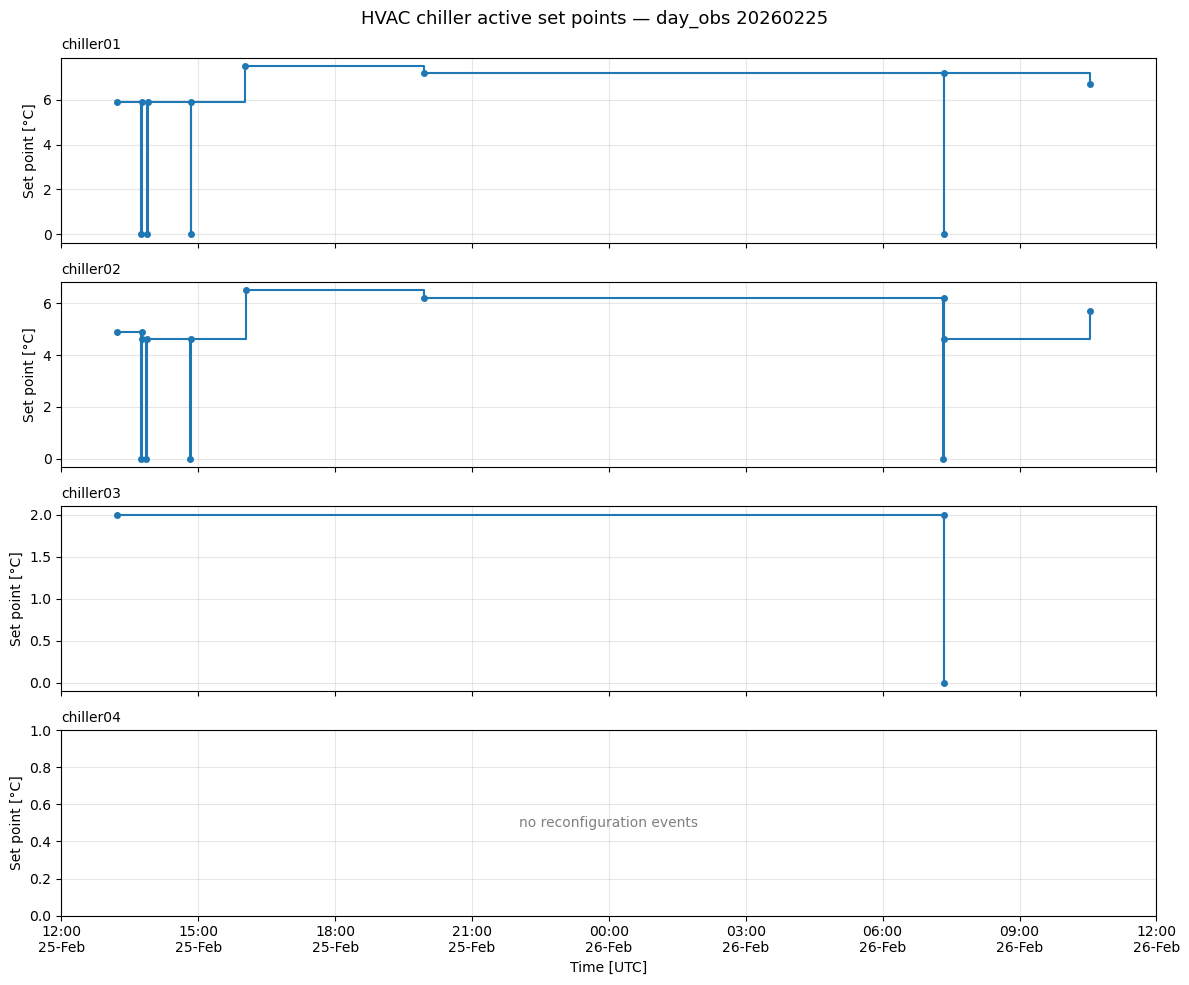

In [11]:
# tz-aware UTC limits so empty panels still span the full night.
x_lo = pd.Timestamp(begin.utc.datetime, tz="UTC")
x_hi = pd.Timestamp(end.utc.datetime, tz="UTC")

fig, axes = plt.subplots(4, 1, sharex=True, figsize=(12, 10))

for ax, (dev_id, name) in zip(axes, CHILLERS.items()):
    g = df[df["device_id"] == dev_id].sort_index() if len(df) else df

    if len(g):
        ax.step(g.index, g["activeSetpoint"], where="post", marker="o", ms=4)
    else:
        ax.text(
            0.5,
            0.5,
            "no reconfiguration events",
            transform=ax.transAxes,
            ha="center",
            va="center",
            color="0.5",
        )

    ax.set_title(name, loc="left", fontsize=10)
    ax.set_ylabel("Set point [°C]")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlim(x_lo, x_hi)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M\n%d-%b"))
axes[-1].set_xlabel("Time [UTC]")

fig.suptitle(
    f"HVAC chiller active set points — day_obs {day_obs}", fontsize=13
)
fig.tight_layout()

plots_dir = "plots"
os.makedirs(plots_dir, exist_ok=True)
fig.savefig(f"{plots_dir}/chiller_setpoints_{day_obs}.png", dpi=150, bbox_inches="tight")

## Change-log table

Keep only rows where the set point actually moved (per chiller). This also drops redundant
re-publications (e.g. a CSC restart re-emits the current config unchanged).

In [12]:
if len(df):
    changes = (
        df.sort_index()
        .groupby("device_id")["activeSetpoint"]
        .apply(lambda s: s[s.diff().ne(0)])  # first row + genuine changes only
        .reset_index()
        .rename(columns={"level_1": "time"})
    )
    changes["chiller"] = changes["device_id"].map(CHILLERS)
    changes["delta_C"] = changes.groupby("device_id")["activeSetpoint"].diff()
    display(changes[["time", "chiller", "activeSetpoint", "delta_C"]])
else:
    print("No configuration events for this day_obs.")

,time,chiller,activeSetpoint,delta_C
0,2026-02-25 13:13:32.834799+00:00,chiller01,5.9,NaN
1,2026-02-25 13:45:00.010510+00:00,chiller01,0.0,-5.9
2,2026-02-25 13:46:07.818526+00:00,chiller01,5.9,5.9
3,2026-02-25 13:52:31.797523+00:00,chiller01,0.0,-5.9
4,2026-02-25 13:53:43.095339+00:00,chiller01,5.9,5.9
5,2026-02-25 14:50:08.250077+00:00,chiller01,0.0,-5.9
6,2026-02-25 14:51:04.613316+00:00,chiller01,5.9,5.9
7,2026-02-25 16:02:05.511838+00:00,chiller01,7.5,1.6
8,2026-02-25 19:57:23.217594+00:00,chiller01,7.2,-0.3
9,2026-02-26 07:20:12.359857+00:00,chiller01,0.0,-7.2
